# Portfolio Optimization and Asset Pricing (MPT & CAPM)
Author: Drew Glover

Date: March 31, 2026


1. The Idea: The Why and the What

  This project tackles the two foundational questions of modern finance:

  **Modern Portfolio Theory (MPT)**: How can we combine risky assets to build a portfolio that has the best possible return for a given level of risk? This is the science of diversification.

  **Capital Asset Pricing Model (CAPM)**: For any single stock, how much return should we expect for the level of market risk we are taking? This is the theory of pricing risk.


2. The Use Case: The Real-World Problem

  **Scenario**: We are a junior portfolio manager at a new fund. Our task is to create a new equity portfolio from a list of prominent S&P 500 stocks.



**Problems to Solve**:

  **The Allocation Problem (MPT)**: How much capital should we allocate to each stock? We need a data-driven method to find the portfolio allocation that offers the best trade-off between risk and return (i.e., the highest Sharpe Ratio).


  **The Asset Pricing Problem (CAPM)**: How can we judge the historical performance of each individual stock? We need to determine if a stock's returns have been fair for the market risk it carries, or if it has generated "alpha."

In [1]:
# Importing Fundamental Libraries Required For The Class
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.optimize as optimization
from scipy import stats

class PortfolioOptimizer:
    """
    A Class to perform portfolio optimization and analysis using the Modern Portfolio Theory.
    It will take the list of stocks and a time period, then finds the optimal portfolio with that maximizes the Sharpe Ratio.
    """
    trading_days = 252

    def __init__(self, stocks, start_date, end_date, risk_free_rate, market_index='^GSPC'):
        """
        Initializes the PortfolioOptimizer object.
        Parameters:
        1. stocks (list): List of stocks for the potfolio.
        2. start_date (str): Start date for historical data (yyyy-mm-dd).
        3. end_date (str): End date for historical data (yyyy-mm-dd).
        4. risk_free_rate (float): Annualized risk-free rate.
        5. market_index (str): The ticker for the market benchmark, defaults to S&P 500.
        """
        # Store the initial parameters passed by the user.
        self.stocks = stocks
        self.market_index = market_index
        self.start_date = start_date
        self.end_date = end_date
        self.risk_free_rate = risk_free_rate
        self.num_stocks = len(stocks)

        # Create empty attributes which will store our data at a later stage.
        self.price_data = None
        self.log_returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.portfolio_results = None
        self.optimal_solution = None
        self.beta_values = None
        self.alpha_values = None


In [2]:
def _download_data(self):
    """
    An internal helper function to download the stock price data for the list of stocks that will be entered by the user.
    Underscore at the beginning indicates that this definition is used internally by the class and not intended for user.
    """
    print("Downloading the historical price data...")

    # Access objects own properties to get the tickets and dates.
    all_assets = self.stocks + [self.market_index]
    price_data = yf.download(all_assets, start = self.start_date, end = self.end_date)['Close']

    # Perform checks for missing data.
    if price_data.isnull().values.any():
        print("Missing data found. Filling the missing data with forward fill approach.")
        price_data.fillna(method = 'ffill', inplace=True)
    else:
        print("No missing data found.")

    # Store the final, cleaned data in the object's memory.
    self.price_data = price_data
    print("\nData download complete.")
    print(price_data.head())

# Attaching this new function to the original Class.
PortfolioOptimizer._download_data = _download_data

In [3]:
def _calculate_returns(self):
    """
    An internal helper function to calculate the daily log returns for the price data.
    """
    # Check to ensure the price data exists or not.
    if self.price_data is None:
        print("No price data found. Running _download_data() first...")
        self._download_data()

    print("Calculating daily log returns...")

    # Calculate the daily log returns using the data stored in the object.
    self.log_returns = np.log(self.price_data / self.price_data.shift(1))

    # Selecting cleaned data by dropping first row of NaNs.
    self.log_returns = self.log_returns.dropna()
    print("Log returns calculation complete.")

# Attaching this new function to the original class.
PortfolioOptimizer._calculate_returns = _calculate_returns

In [4]:
def _calculate_mpt_inputs(self):
    """
    An internal helper function to calculate the annualized mean retuns and the covariance matrix.
    """
    # Ensure the log returns have been calculated first.
    if self.log_returns is None:
        print("Log returns not found. Running _calculate_returns() first...")
        self._calculate_returns()

    print("Calculating annualizd MPT inputs (mean returns and covariance matrix)...")

    # Calculate and store the anualized mean returns for the stocks only
    self.mean_returns = self.log_returns[self.stocks].mean() * self.trading_days

    # Calculate amd store the covariance matrix
    self.cov_matrix = self.log_returns[self.stocks].cov() * self.trading_days

    print("MPT Inputs calculations complete.")

PortfolioOptimizer._calculate_mpt_inputs = _calculate_mpt_inputs

In [5]:
def run_mpt_simulations(self, num_portfolios = 20000):
    """
    Runs the full Monte Carlo Simulations for MPT by generating thousands of random portfolios and calucating their performance metrics.
    """
    # Ensure all the pre-requisites are present before moving ahead.
    if self.mean_returns is None or self.cov_matrix is None:
        print("MPT inputs not found. Running _calculate_mpt_inputs() first...")
        self._calculate_mpt_inputs()

    print("Running the Monte Carlo Simulations for {num_portfolio} portfolios...")

    # Setting up empty lists to store the results
    returns_list, volatility_list, sharpe_ratio_list = [], [], []

    for _ in range(num_portfolios):
        # Generate and normalise random weights
        weights = np.random.random(self.num_stocks)
        weights = weights / np.sum(weights)

        # Calculate performance of a random portfolio
        ret, vol, sr = get_portfolio_performance(weights, self.mean_returns, self.cov_matrix, self.risk_free_rate)

        # Append the results to the emprt lists
        returns_list.append(ret)
        volatility_list.append(vol)
        sharpe_ratio_list.append(sr)

    # Store the final results in the dataframe inside the object
    self.portfolio_results = pd.DataFrame({'return': returns_list,
                                          'volatility': volatility_list,
                                          'sharpe_ratio': sharpe_ratio_list})

    print("MPT Simulation complete.")

PortfolioOptimizer.run_mpt_simulations = run_mpt_simulations

# Defining the utility function get_portfolio_performance
def get_portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate):
    """
    Calculate the returns, volatility and sharpe ratio for a given set of weights.
    """
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

In [6]:
def find_optimal_portfolio(self):
    """
    Runs the numerial optimization to find the portfolio with the maximum sharpe ratio.
    """
    # Check to ensure we have MPT inuts necessart for this calculation.
    if self.mean_returns is None or self.cov_matrix is None:
        print("MPT Calclations missing. Running _calculate_mpt_inputs first...")
        self._calculate_mpt_inputs()

    print("Finding the optimal portfolio using the numerical calculations...")

    # Function to minimize (the negative sharpe ratio)
    def get_negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
        _, _, sharpe_ratio = get_portfolio_performance(weights, self.mean_returns, self.cov_matrix, self.risk_free_rate)
        return -sharpe_ratio

    # Define the constraints and bounds for the optimizer function.
    constraint = ({"type": "eq", "fun": lambda weights: np.sum(weights)-1})
    bounds = tuple((0,1) for _ in range(self.num_stocks))
    initial_guess = self.num_stocks * [1. / self.num_stocks]

    # Run the optimizer function
    optimal_solution = optimization.minimize(fun = get_negative_sharpe_ratio,
                                             x0 = initial_guess,
                                             args = (self.mean_returns, self.cov_matrix, self.risk_free_rate),
                                             method = 'SLSQP',
                                             constraints = constraint,
                                             bounds = bounds)

    # Store the entire solution object for later inspection
    self.optimal_solution = optimal_solution
    print("Optimization complete.")

PortfolioOptimizer.find_optimal_portfolio = find_optimal_portfolio

In [7]:
def plot_efficient_frontier(self):
    """
    Plot the efficient frontier from the Monte Carlo Simulations results and highlughts the optimal portfolio.
    """
    # Ensure all pre-requisites are satisfied before plotting.
    if self.portfolio_results is None or self.optimal_solution is None:
        print("Error: Please run the run_mpt_simulations() and find_optimal_portfolio() before plotting.")
        return

    print("Generating Efficient Frontier plot...")

    # Extract the optimal portfolio performance
    optimal_weights = self.optimal_solution.x
    opt_ret, opt_vol, _ = get_portfolio_performance(optimal_weights, self.mean_returns, self.cov_matrix, self.risk_free_rate)

    # Create the base of the scatter plot
    plt.figure(figsize=(10,7))
    plt.scatter(self.portfolio_results['volatility'],
                self.portfolio_results['return'],
                c = self.portfolio_results['sharpe_ratio'],
                cmap = 'viridis')
    plt.title("Efficient Forntier with Optimal Portfolio")
    plt.xlabel("Annualzied Volatility")
    plt.ylabel("Annualized Return")
    plt.colorbar(label = "Sharpe Ratio")
    plt.grid(True)
    plt.scatter(opt_vol, opt_ret, marker = '*', color='red', s=100, label='Optimal Portfolio')
    plt.legend()
    plt.show()

PortfolioOptimizer.plot_efficient_frontier = plot_efficient_frontier


In [8]:
def _calculate_capm_metrics(self):
    """
    An internal helper function to calculate the Beta and Jensen's Alpha for all stocks.
    """
    print("Calculating CAPM Metrics (Beta and Alpha)...")

    # Ensure that the returns have been calculated first.
    if self.log_returns is None:
        print("Log Returns not found. Running the _calculate_returns() first...")
        self._calculate_returns()

    # Prepare data fro regression
    daily_risk_free_rate = self.risk_free_rate / self.trading_days
    stock_excess_returns = self.log_returns.subtract(daily_risk_free_rate, axis=0)
    market_excess_returns = self.log_returns[self.market_index].subtract(daily_risk_free_rate, axis=0)

    # Setup dictionaries to store  the values
    self.beta_values = {}
    self.alpha_values = {}

    # Loop thoru each stock to run the regression
    for stock in self.stocks:
        regression_data = pd.concat([stock_excess_returns[stock], market_excess_returns], axis=1).dropna()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x=regression_data.iloc[:, 1],
                                                                       y=regression_data.iloc[:, 0])
        self.beta_values[stock] = slope
        self.alpha_values[stock] = intercept * self.trading_days

PortfolioOptimizer._calculate_capm_metrics = _calculate_capm_metrics

In [9]:
def analyze_and_plot_capm(self):
    """
    Performs the full CAPM analysis on all stocks in the portfolio and
    plots the Security Market Line (SML) to visualize their performance.
    """
    # This is the orchestrator. It first ensures that the necessary CAPM metrics have been calculated by calling its internal helper method.
    print("\n--- Starting CAPM Analysis ---")
    if self.beta_values is None or self.alpha_values is None:
        print("CAPM metrics not found. Running calculations...")
        self._calculate_capm_metrics()

    print("\nGenerating the Security Market Line plot...")

    # Calculate the annualized mean return of the market index
    market_mean_return_annual = self.log_returns[self.market_index].mean() * self.trading_days

    # Create the theoretical Security Market Line. We generate a range of hypothetical Betas to draw the line
    beta_range = np.linspace(0, max(2.5, max(self.beta_values.values()) + 0.5), 100)
    sml_values = self.risk_free_rate + beta_range * (market_mean_return_annual - self.risk_free_rate)

    plt.figure(figsize=(12, 7))

    # 1. Plot the SML line
    plt.plot(beta_range, sml_values, color='navy', linestyle='--', label='Security Market Line (SML)')

    # 2. Plot the individual stocks on the graph
    # X-axis is the stock's calculated Beta
    # Y-axis is the stock's actual historical mean return
    plt.scatter(list(self.beta_values.values()), self.mean_returns.values, color='red', s=100, label='Portfolio Stocks')

    # 3. Annotate each point with the stock's ticker
    for stock, beta in self.beta_values.items():
        plt.text(beta + 0.02,
                 self.mean_returns[stock],
                 stock,
                 fontsize=9)

    # 4. Finalize the plot with labels and title
    plt.title('Capital Asset Pricing Model (CAPM) - Security Market Line')
    plt.xlabel('Beta (Systematic Risk)')
    plt.ylabel('Annualized Return')
    plt.legend()
    plt.grid(True)
    plt.show()

PortfolioOptimizer.analyze_and_plot_capm = analyze_and_plot_capm

--- Starting Final Portfolio Analysis ---
MPT inputs not found. Running _calculate_mpt_inputs() first...
Log returns not found. Running _calculate_returns() first...
No price data found. Running _download_data() first...


/tmp/ipython-input-707032882.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(all_assets, start = self.start_date, end = self.end_date)['Close']
[*********************100%***********************]  7 of 7 completed


No missing data found.

Data download complete.
Ticker        AMD         BLK          DE         LMT        NEE         UNH  \
Date                                                                           
2018-01-02  10.98  420.668732  141.223282  261.119049  32.241417  197.135864   
2018-01-03  11.55  425.107269  141.866806  263.307648  31.557468  199.203812   
2018-01-04  12.12  430.719116  142.680115  267.824341  31.395315  200.068436   
2018-01-05  11.88  434.388916  143.287933  270.250854  31.538752  203.883514   
2018-01-08  12.28  437.628815  143.993942  269.004791  31.798607  200.344788   

Ticker            ^GSPC  
Date                     
2018-01-02  2695.810059  
2018-01-03  2713.060059  
2018-01-04  2723.989990  
2018-01-05  2743.149902  
2018-01-08  2747.709961  
Calculating daily log returns...
Log returns calculation complete.
Calculating annualizd MPT inputs (mean returns and covariance matrix)...
MPT Inputs calculations complete.
Running the Monte Carlo Simulations

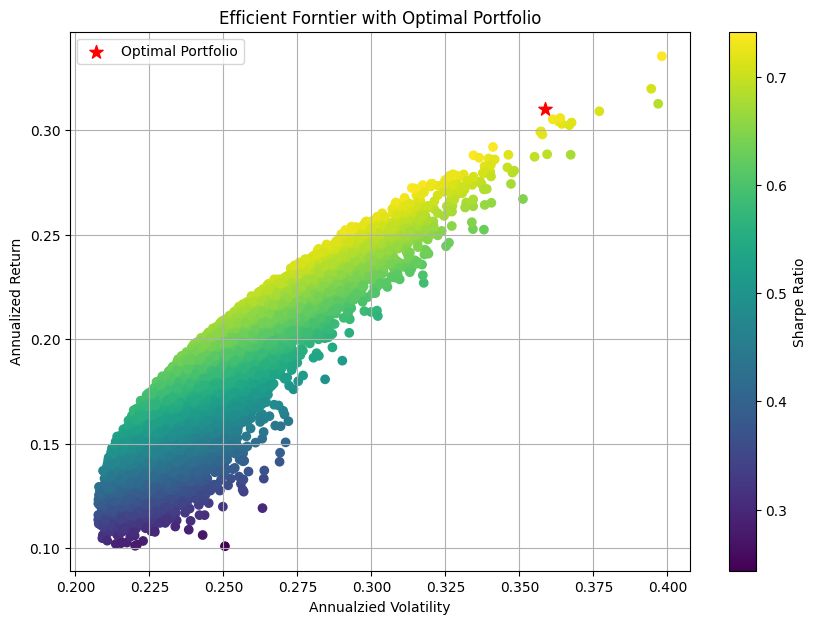


--- Starting CAPM Analysis ---
CAPM metrics not found. Running calculations...
Calculating CAPM Metrics (Beta and Alpha)...

Generating the Security Market Line plot...


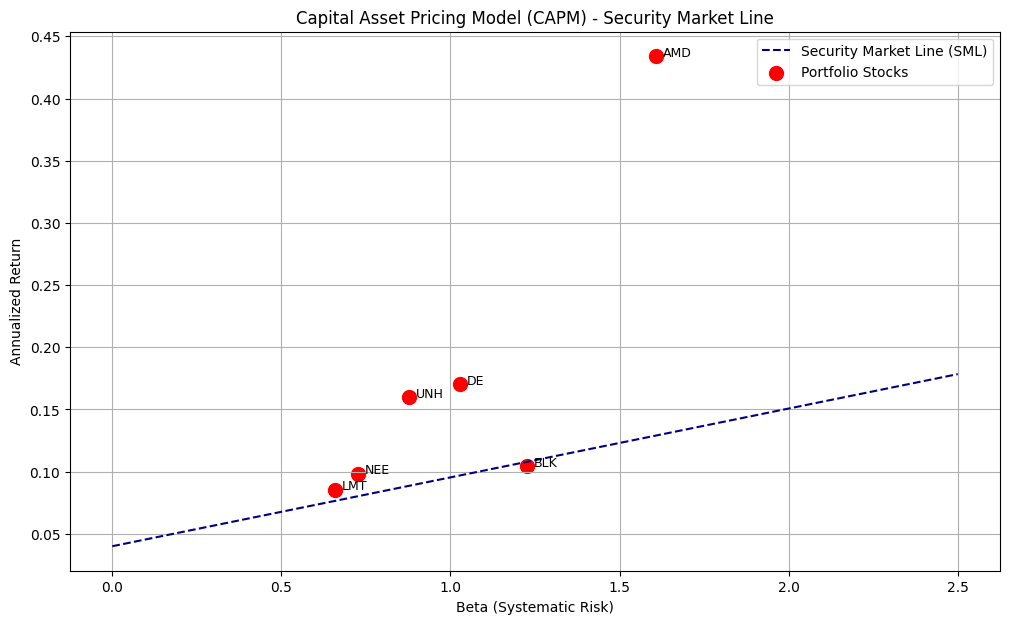


--- Capital Asset Pricing Model (CAPM) Results ---
Calculated Betas:
- UNH: 0.8787
- NEE: 0.7273
- LMT: 0.6592
- DE: 1.0292
- BLK: 1.2257
- AMD: 1.6085

Calculated Annualized Alphas (Jensen's Alpha):
- UNH: 7.10%
- NEE: 1.81%
- LMT: 0.90%
- DE: 7.33%
- BLK: -0.37%
- AMD: 30.50%

--- Analysis Complete ---


In [10]:
# 1. Define the parameters for our final, presentation-quality analysis
final_stocks = ['UNH', 'NEE', 'LMT', 'DE', 'BLK', 'AMD']
final_market_index = '^GSPC'
final_start_date = '2018-01-01'
final_end_date = '2023-12-31'
final_risk_free_rate = 0.04

print("--- Starting Final Portfolio Analysis ---")

# 2. Create the final PortfolioOptimizer instance from our blueprint
# This single object will contain all our data and results.
final_optimizer = PortfolioOptimizer(stocks=final_stocks,
                                     start_date=final_start_date,
                                     end_date=final_end_date,
                                     risk_free_rate=final_risk_free_rate,
                                     market_index=final_market_index)

# 3. Run the complete MPT analysis
final_optimizer.run_mpt_simulations(num_portfolios=20000)
final_optimizer.find_optimal_portfolio()

# 4. Display the key MPT results in a clean, formatted way
print("\n--- Modern Portfolio Theory (MPT) Results ---")
print("Optimal Portfolio Allocation (Maximum Sharpe Ratio):")
optimal_weights = final_optimizer.optimal_solution.x
for stock, weight in zip(final_optimizer.stocks, optimal_weights):
    print(f"- {stock}: {weight:.2%}")

# Calculate and display the performance of this optimal portfolio
opt_return, opt_vol, opt_sharpe = get_portfolio_performance(optimal_weights,
                                                           final_optimizer.mean_returns,
                                                           final_optimizer.cov_matrix,
                                                           final_optimizer.risk_free_rate)
print(f"\nExpected Annual Return: {opt_return:.2%}")
print(f"Expected Annual Volatility: {opt_vol:.2%}")
print(f"Sharpe Ratio: {opt_sharpe:.2f}")

# 5. Generate the final MPT plot
final_optimizer.plot_efficient_frontier()

# 6. Run the complete CAPM analysis
final_optimizer.analyze_and_plot_capm()

# 7. Display the key CAPM results
print("\n--- Capital Asset Pricing Model (CAPM) Results ---")
print("Calculated Betas:")
for stock, beta in final_optimizer.beta_values.items():
    print(f"- {stock}: {beta:.4f}")

print("\nCalculated Annualized Alphas (Jensen's Alpha):")
for stock, alpha in final_optimizer.alpha_values.items():
    print(f"- {stock}: {alpha:.2%}")

print("\n--- Analysis Complete ---")

# Conclusions and Learnings

This project successfully implemented the two foundational models of modern finance: Modern Portfolio Theory (MPT) and the Capital Asset Pricing Model (CAPM).

---

### **Part A: Modern Portfolio Theory (MPT) Findings**

*   **Achievement:** We successfully used a Monte Carlo simulation and a numerical optimizer to identify the **Optimal Risky Portfolio** from our universe of six diverse US stocks.
*   **The Result:** The optimal allocation, based on historical data from 2018-2023, was heavily weighted towards some stocks for their high growth and some stocks for their low-risk, diversifying properties. This portfolio offered the highest possible Sharpe Ratio.
*   **Key Learning (The "Real World Scenario"): The "Garbage In, Garbage Out" Problem.**
    *   MPT is a powerful framework, but its output is extremely sensitive to its inputs (mean returns, volatilities, and correlations).
    *   We used *historical* data to calculate these inputs. In the real world, there is **no guarantee** that past returns or correlations will persist in the future. In fact, they almost certainly won't.
    *   **Conclusion:** MPT is better at explaining the *concept* of diversification than at providing a precise, tradable portfolio for the future. A real quant fund would spend 99% of its effort on developing superior *forecasts* for the inputs, rather than just running the optimizer.

---

### **Part B: Capital Asset pricing Model (CAPM) Findings**

*   **Achievement:** We successfully calculated the **Beta** and **Jensen's Alpha** for each individual stock and visualized their risk/return profile on the **Security Market Line (SML)**.
*   **The Result:** Our analysis clearly identified which stocks were historical outperformers and underperformers on a risk-adjusted basis.
    *   **High Alpha:** The stocks here delivered returns far beyond what its high market risk would predict.
    *   **Zero/Negative Alpha:** These stocks performed almost exactly as the CAPM predicted, delivering a fair return for its low risk.
*   **Key Learning: The Unrealistic Assumptions.**
    *   The CAPM provides a beautiful, intuitive theory for the relationship between risk and return.
    *   However, its foundational assumptions (listed in the FRM slides, e.g., no transaction costs, all investors are rational, etc.) are **known to be false** in the real world.
    *   **Conclusion:** CAPM is an essential theoretical benchmark for understanding concepts like Beta and systematic risk. However, because its assumptions do not hold, it is not used by modern quant funds to generate "alpha" signals. Real alpha is found by exploiting the very market frictions and irrational behaviors that the CAPM assumes away.

---

### **Overall Project Conclusion**

By building these models from scratch, we have not only implemented the textbook theories but have also gained a critical appreciation for their real-world limitations. This understanding - knowing what a model is good for and, more importantly, what it is *not* good for - is the hallmark of a professional quantitative researcher.